   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  

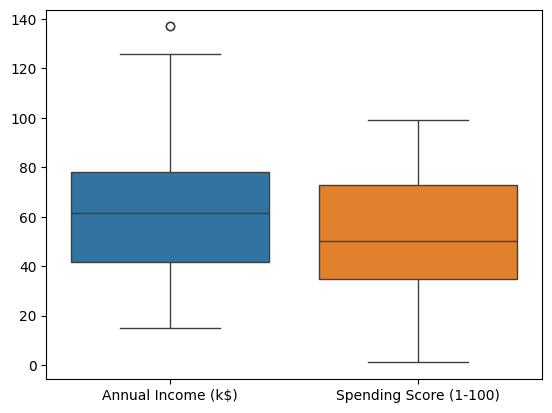

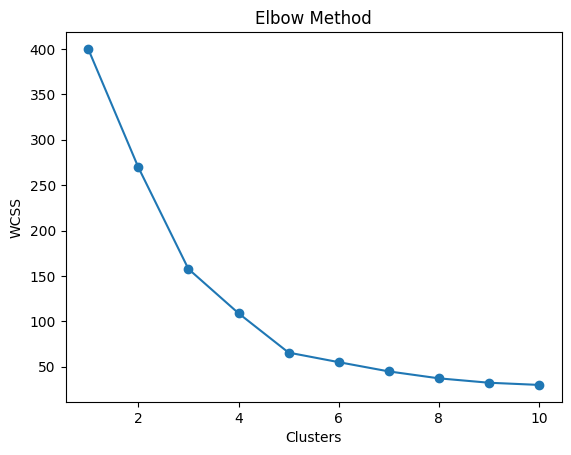

Clusters: 2 Silhouette Score: 0.3212707813918878
Clusters: 3 Silhouette Score: 0.46658474419000145
Clusters: 4 Silhouette Score: 0.4939069237513199
Clusters: 5 Silhouette Score: 0.5546571631111091
Clusters: 6 Silhouette Score: 0.5398800926790663


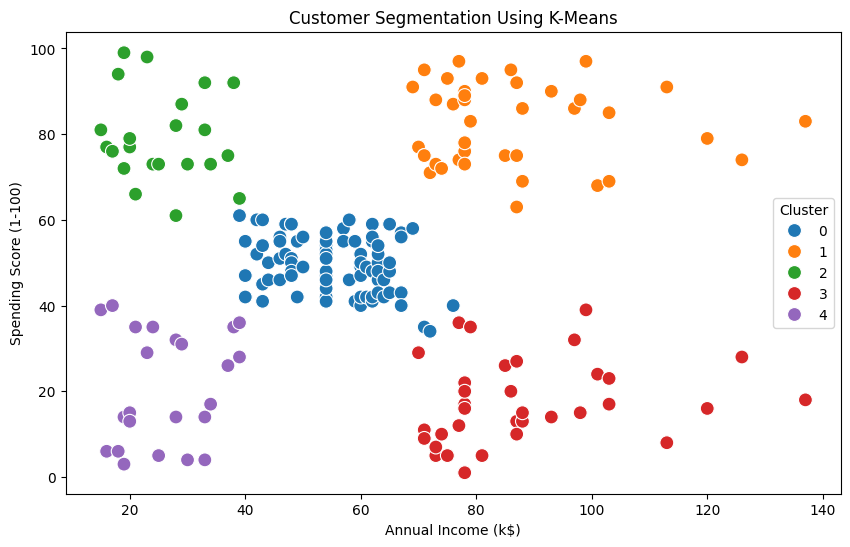

         Annual Income (k$)  Spending Score (1-100)  Cluster Size
Cluster                                                          
0                 55.296296               49.518519            81
1                 86.538462               82.128205            39
2                 25.727273               79.363636            22
3                 88.200000               17.114286            35
4                 26.304348               20.913043            23


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df=pd.read_csv('Mall_Customers.csv')

print(df.head())
print(df.info())
print(df.describe())

sns.boxplot(data=df[['Annual Income (k$)','Spending Score (1-100)']])
plt.show()

df.dropna(inplace=True)

X=df[['Annual Income (k$)','Spending Score (1-100)']]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.show()

for k in range(2,7):
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=km.fit_predict(X_scaled)
    print('Clusters:',k,'Silhouette Score:',silhouette_score(X_scaled,labels))

kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)
df['Cluster']=kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Annual Income (k$)'],y=df['Spending Score (1-100)'],hue=df['Cluster'],palette='tab10',s=100)
plt.title('Customer Segmentation Using K-Means')
plt.show()

cluster_summary=df.groupby('Cluster').agg({
'Annual Income (k$)':'mean',
'Spending Score (1-100)':'mean',
'CustomerID':'count'
}).rename(columns={'CustomerID':'Cluster Size'})

print(cluster_summary)